## Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib
from matplotlib import pyplot as plt
import pathlib

from utils import dataloader, connect_gt_and_pred, calculate_error_distributions

from statsforecast import StatsForecast
from neuralforecast import NeuralForecast
from neuralforecast.losses.numpy import mae, mse, rmse

c:\Program Files\Anaconda3\envs\BGformer\lib\site-packages\statsforecast\core.py:26: TqdmExperimentalWarning: Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)
  from tqdm.autonotebook import tqdm


## Load model and environment

In [2]:
config = {
        'normalize': True,
        'horizon': 3,
        'snippet_length': 21,
        'train_dataset': 'ICU_train',
        'test_dataset': 'ICU_test',
}

horizon = config['horizon']
snippet_length = config['snippet_length']

In [3]:
model_path = "models/2025_04_30_22_01"

models = NeuralForecast.load(path=model_path)

print("Training date and time: ", model_path[7:])
print("Trained model(s): ", models.models)


Seed set to 1


Training date and time:  2025_04_30_22_01
Trained model(s):  [TimesNet]


## Load and prep data

In [4]:
print('Loading dataset: ', config['test_dataset'])
data = dataloader(config=config, train=False)
Y_df = data.find_all_continuous_snippets(hours=snippet_length)
print('Done!')

Loading dataset:  ICU_test


Done!


In [5]:
# drop last horizon length y values for prediction
ids_to_drop = [i for i in range(len(Y_df)) if i % snippet_length >= snippet_length-horizon]
ids_to_drop_for_comparison = [i for i in range(len(Y_df)) if i % snippet_length < snippet_length-horizon]
Y_df_gt_window = Y_df.drop(ids_to_drop)
Y_df_gt_horizon = Y_df.drop(ids_to_drop_for_comparison)

## Run prediction

In [6]:
Y_hat_df_2 = models.predict(df=Y_df_gt_window).reset_index()

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
You are using a CUDA device ('NVIDIA GeForce RTX 4080 SUPER') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Predicting: |          | 0/? [00:00<?, ?it/s]

c:\Program Files\Anaconda3\envs\BGformer\lib\site-packages\neuralforecast\core.py:196: FutureWarning: In a future version the predictions will have the id as a column. You can set the `NIXTLA_ID_AS_COL` environment variable to adopt the new behavior and to suppress this warning.
  warnings.warn(


## Clip and denormalize predictions

In [7]:
for model in models.models:
    Y_hat_df_2[str(model)] = Y_hat_df_2[str(model)].clip(lower=0.0)

if config['normalize']:

    # denormalize GT values
    Y_df_gt_horizon['y'] = data.scaler.inverse_transform(Y_df_gt_horizon['y'].values.reshape(-1,1))
    Y_df['y'] = data.scaler.inverse_transform(Y_df['y'].values.reshape(-1,1))
    
    # denormalize predicted values
    for model in models.models:
        Y_hat_df_2[str(model)] = data.scaler.inverse_transform(Y_hat_df_2[str(model)].values.reshape(-1,1))

## Calculate and plot metrics and results

In [8]:
# calculate metrics
metrics_cols = ['Model Name', 'MAE', 'MSE', 'RMSE']
metrics = pd.DataFrame(columns=metrics_cols)
for model in models.models:
    model_metrics = {metrics_cols[0]: str(model)}
    model_metrics['MAE'] = mae(Y_hat_df_2[str(model)], Y_df_gt_horizon['y'])
    model_metrics['MSE'] = mse(Y_hat_df_2[str(model)], Y_df_gt_horizon['y'])
    model_metrics['RMSE'] = rmse(Y_hat_df_2[str(model)], Y_df_gt_horizon['y'])

    model_metrics_df = pd.DataFrame(model_metrics, index=[0])
    metrics = pd.concat([metrics, model_metrics_df], ignore_index=True)

Started merging function


Cutoff timestamps appended


100%|██████████| 52620/52620 [00:35<00:00, 1477.06it/s]


0 0.010198624456131459
1 0.00959003681858778
2 0.009179764078760148




  Model name Statistic       t+1       t+2       t+3
0   TimesNet      Mean  0.000330  0.000319  0.000315
1   TimesNet       Std  0.000295  0.000276  0.000262


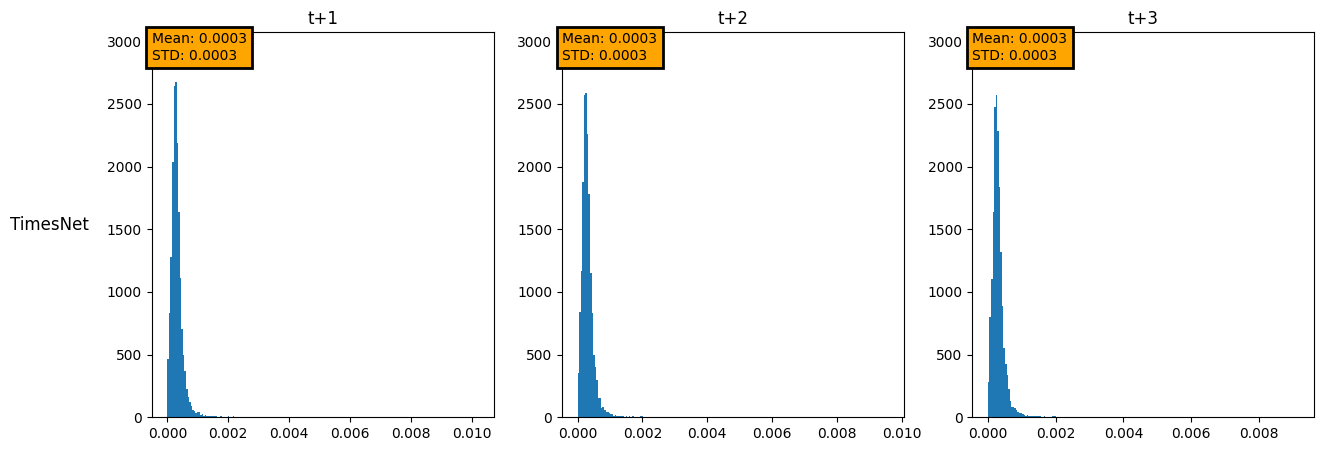

In [9]:
df_to_plot_2 = connect_gt_and_pred(df_gt=Y_df, df_pred=Y_hat_df_2, snippet_length=snippet_length, horizon=horizon)
prediction_graphs = StatsForecast.plot(Y_df, df_to_plot_2.drop(columns=['y', 'cutoff']), max_insample_length=1260)
histograms, means_stds_df = calculate_error_distributions(Y_df_gt_horizon, Y_hat_df_2, models=models, horizon=horizon)

## Visualize

In [10]:
histograms.show()

C:\Users\msz30\AppData\Local\Temp\ipykernel_25268\3154352931.py:1: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  histograms.show()
